In [1]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.utils.data import download_file
from astropy.io import fits, ascii
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
from astropy.table import vstack, hstack

import pyvo

from wise_light_curves import *

In [2]:
meta = pd.read_csv('../ecle-meta-data.csv')
meta

,name,ra,ra_unit,dec,dec_unit,coord_ref,discovery_date,discovery_date_format,discovery_date_ref,redshift,redshift_ref,classification,classification_ref,radio_data,radio_data_comment,otter,otter_comments
0,2019qiz,04:46:37.880,hour,-10:13:34.90,degree,2019TNSTR1857....1F,2458745.9998032,JD,2019TNSTR1857....1F,0.015100,2019TNSTR1857....1F,TDE,2019TNSCR1921....1S,True,"Kate (very good radio dataset, still need to a...",True,good uvoir dataset
1,SDSS_J0748,07:48:20.6668,hour,+47:12:14.2648,degree,2024arXiv240216951C,2004-02-20,iso,2024MNRAS.528.7076C,0.061600,2024arXiv240216951C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available
2,SDSS_J0807,08:07:27.3157,hour,+14:05:37.0892,degree,2024arXiv240216951C,2005-11-08,iso,2024arXiv240216951C,0.073800,2024arXiv240216951C,AGN,2024arXiv240216951C,True,VLASS,False,NaN
3,SDSS_J0938,09:38:01.6376,hour,+13:53:17.0423,degree,2024arXiv240216951C,2006-12-23,iso,2024MNRAS.528.7076C,0.101000,2024arXiv240216951C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN
4,SDSS_J0952,09:52:09.5629,hour,+21:43:13.2979,degree,2024arXiv240216951C,2005-12-30,iso,2024MNRAS.528.7076C,0.079500,2024arXiv240216951C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available
5,SDSS_J1055,10:55:26.4177,hour,+56:37:13.1010,degree,2024arXiv240216951C,2002-04-09,iso,2024MNRAS.528.7076C,0.074000,2024arXiv240216951C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN
6,SDSS_J1207,12:07:19.8102,hour,+24:11:55.8789,degree,2024arXiv240216951C,2008-01-19,iso,2024arXiv240216951C,0.050300,2024arXiv240216951C,AGN,2024arXiv240216951C,True,VLASS,False,NaN
7,SDSS_J1241,12:41:34.2561,hour,+44:26:39.2636,degree,2024arXiv240216951C,2004-02-27,iso,2024MNRAS.528.7076C,0.041900,2024arXiv240216951C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS, 4 other observations from other p...",False,NaN
8,SDSS_J1247,12:47:26.3719,hour,+07:05:25.0809,degree,2024arXiv240216951C,2006-05-21,iso,2024arXiv240216951C,0.104000,2024arXiv240216951C,AGN,2024arXiv240216951C,True,VLASS,False,NaN
9,SDSS_J1342,13:42:44.4150,hour,+05:30:56.1451,degree,2024arXiv240216951C,2002-04-09,iso,2024MNRAS.528.7076C,0.036500,2024arXiv240216951C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,minimal uvoir


In [3]:
# some variables for changing things in how we do this
radius = 5 # arcseconds
overwrite = False

# from https://www.cambridge.org/core/journals/publications-of-the-astronomical-society-of-australia/article/recalibrating-the-widefield-infrared-survey-explorer-wise-w4-filter/B238BFFE19A533A2D2638FE88CCC2E89
band_vals={'w1':3.4,'w2':4.6,'w3':12,'w4':22} # in um
keep_in_order = ['internal_name', 'date_mjd', 'filter', 'filter_eff', 'filter_eff_unit', f'flux', f'flux_err', 'flux_unit', 'upperlimit']

wise_data = []
for ii, row in meta.iterrows():
    #     print()
    #     print('################################################')
    #     print()
    #     print(row['name'])
    
    coord = SkyCoord(row.ra, row.dec, unit=('hour', 'deg'))
    ra, dec = coord.ra.value, coord.dec.value
    
    fbasename = f'wise_{row["name"]}'
    allwise_name = f'{fbasename}_allwise.ipac'
    neowise_name = f'{fbasename}_neowise.ipac'
    
    
    download_single_data(name=fbasename, ra=ra, dec=dec, root_path='ipac/', radius=radius, overwrite=overwrite)
    
    allwise = ascii.read(f'ipac/{allwise_name}', format='ipac')
    neowise = ascii.read(f'ipac/{neowise_name}', format='ipac')
    
    
    allwise, neowise = only_good_data_v1(allwise, neowise)
    if allwise is None or neowise is None:
        print(f'Limited good infrared data for {row["name"]}, skipping!')
        
    mjd, mag, mag_err, filts = make_full_lightcurve_multibands(
        allwise, neowise, bands=['w1', 'w2', 'w3', 'w4']
    )
    
    df = pd.DataFrame(dict(
        name = [row['name']]*len(mjd),
        date_mjd = mjd,
        filter = filts,
        filter_eff = [band_vals[f] for f in filts],
        filter_eff_unit = ['um']*len(mjd),
        flux = mag,
        flux_err = mag_err,
        flux_unit = ['mag(AB)']*len(mjd),
        upperlimit = [False]*len(mjd)
    ))
    
    
    # fig, ax = plt.subplots()
    # ax.errorbar(t, mag, yerr=mag_err, linestyle='none', marker='o')
    # fig.gca().invert_yaxis()
    
    # ax.set_title(row['name'])
    
    wise_data.append(df)

# concatenate and clean the wise data
wise = pd.concat(wise_data)
wise = wise[wise.flux > 0].reset_index(drop=True)

# wise.to_csv('../data/wise-photometry.csv')
wise

Filtered out 102 neowise points, leaving 178
178
Filtered out -120 allwise points, leaving 178
Filtered out 14 neowise points, leaving 262
262
Filtered out -237 allwise points, leaving 262
Filtered out 37 neowise points, leaving 209
209
Filtered out -184 allwise points, leaving 209
Filtered out 62 neowise points, leaving 190
190
Filtered out -168 allwise points, leaving 190
Filtered out 89 neowise points, leaving 162
162
Filtered out -136 allwise points, leaving 162
Filtered out 214 neowise points, leaving 148
148
Filtered out -119 allwise points, leaving 148
Filtered out 128 neowise points, leaving 140
140
Filtered out -116 allwise points, leaving 140
Filtered out 64 neowise points, leaving 294
294
Filtered out -230 allwise points, leaving 294
Filtered out 98 neowise points, leaving 154
154
Filtered out -129 allwise points, leaving 154
Filtered out 55 neowise points, leaving 203
203
Filtered out -166 allwise points, leaving 203
Filtered out 186 neowise points, leaving 135
135
Filtered

/tmp/ipykernel_94612/2407523839.py:60: FutureWarning: Behavior when concatenating bool-dtype and numeric-dtype arrays is deprecated; in a future version these will cast to object dtype (instead of coercing bools to numeric values). To retain the old behavior, explicitly cast bool-dtype arrays to numeric dtype.
  wise = pd.concat(wise_data)


,name,date_mjd,filter,filter_eff,filter_eff_unit,flux,flux_err,flux_unit,upperlimit
0,2019qiz,55247.646228,w1,3.4,um,12.456,0.034,mag(AB),0.0
1,2019qiz,55248.043140,w1,3.4,um,12.527,0.032,mag(AB),0.0
2,2019qiz,55248.109356,w1,3.4,um,12.465,0.036,mag(AB),0.0
3,2019qiz,55248.175444,w1,3.4,um,12.363,0.034,mag(AB),0.0
4,2019qiz,55248.175572,w1,3.4,um,12.453,0.034,mag(AB),0.0
...,...,...,...,...,...,...,...,...,...
12130,AT2018dyk,55396.311957,w4,22.0,um,7.236,0.285,mag(AB),0.0
12131,AT2018dyk,55396.378045,w4,22.0,um,7.708,0.413,mag(AB),0.0
12132,AT2018dyk,55396.444260,w4,22.0,um,6.826,0.225,mag(AB),0.0
12133,AT2018dyk,55396.708740,w4,22.0,um,7.262,0.320,mag(AB),0.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'MJD')

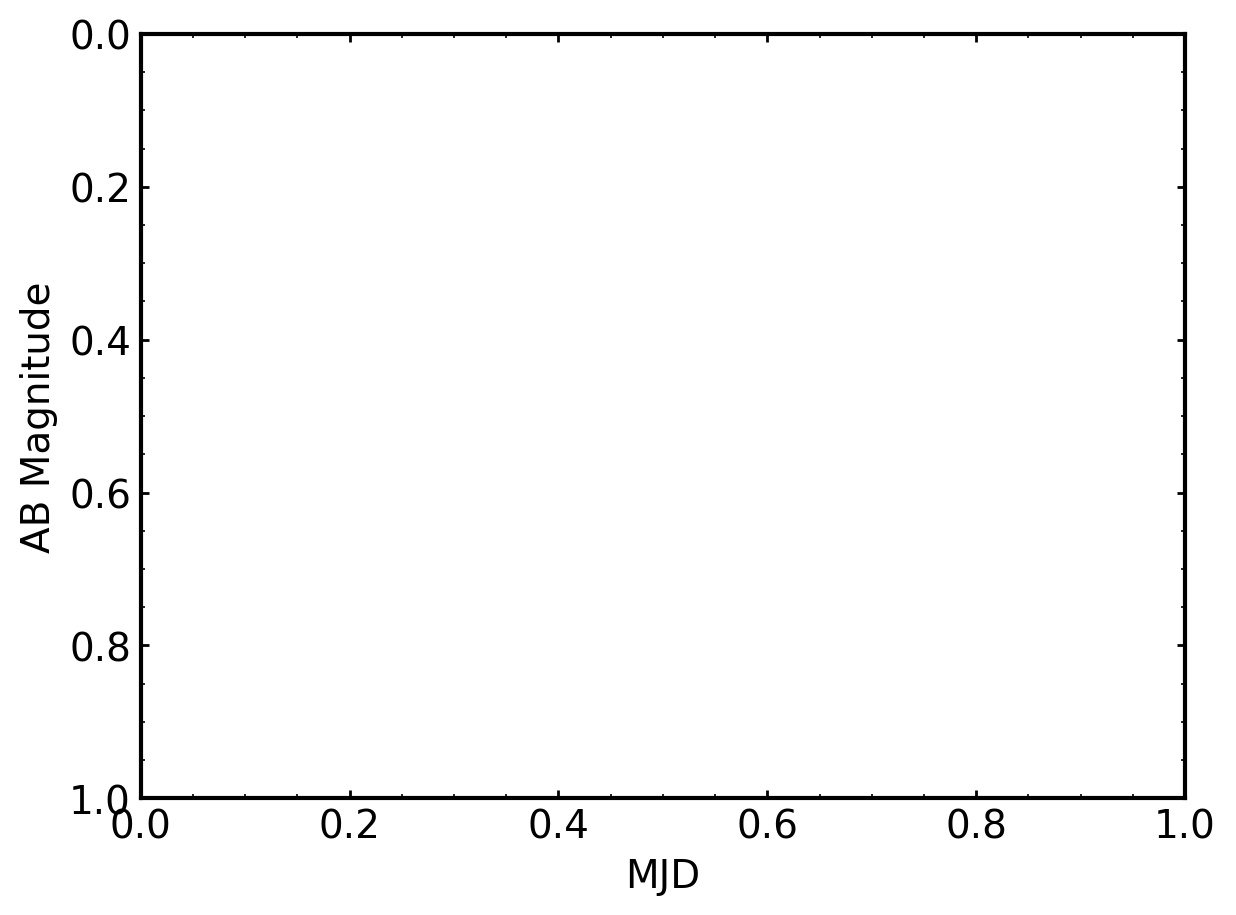

In [4]:
name = 'AT2021qth'

color_map = {'w1':'#ffba49',
             'w2': '#20a39e',
             'w3': '#ef5b5b',
             'w4': 'k'}
dd = wise[wise.name==name]

fig, ax = plt.subplots()

for f,d in dd.groupby('filter'):
    ax.errorbar(d.date_mjd, d.flux, yerr=d.flux_err, color=color_map[f], marker='o', linestyle='none', label=f)
    
ax.legend()
# ax.set_xscale('log')
fig.gca().invert_yaxis()

ax.set_ylabel('AB Magnitude')
ax.set_xlabel('MJD')

In [5]:
wise[wise.name == name]

,name,date_mjd,filter,filter_eff,filter_eff_unit,flux,flux_err,flux_unit,upperlimit
